# Semana 5 — Experimentos A/B

**Proyecto:** Traductor LSP — 26 clases, sliding window 30f  
**Modelo:** ST-GCN sobre landmarks MediaPipe Holistic (carga instantánea desde .npy)  

| ID | Variante | Cambio | Config |
|----|----------|--------|--------|
| **B** | Baseline | — | ST-GCN hidden=64, lr=1e-4 |
| **V1** | Var1 | hidden 64→32 (↓50% parámetros LSTM) | ST-GCN hidden=32, lr=1e-4 |
| **V2** | Var2 | lr 1e-4→5e-4 (más agresivo) | ST-GCN hidden=64, lr=5e-4 |

> Un cambio por vez. Fit solo en train; val solo para early stopping; test evaluado una sola vez al final.

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────
import os, sys, json, time, warnings, datetime
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_curve,
    average_precision_score, classification_report
)
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')

# Detectar entorno Colab vs Local
try:
    from google.colab import drive; IN_COLAB = True
    sys.path.insert(0, '/content/drive/MyDrive/TRADUCTOR_LSP')
except ImportError:
    IN_COLAB = False
    _nb = Path.cwd()
    BASE_DIR = str(_nb.parent if _nb.name == 'notebooks' else _nb)
    sys.path.insert(0, BASE_DIR)
    os.chdir(BASE_DIR)

from src.models import STGCN

DEVICE   = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
N_KP     = 75   # 42 manos + 33 pose
N_FRAMES = 30
BATCH    = 32   # landmarks son pequeños → batch grande es posible
EPOCHS   = 5
CKPT_DIR = Path('checkpoints')
LOG_DIR  = Path('logs')
CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(exist_ok=True)

with open('data/label2idx.json') as f:
    label2idx = json.load(f)
idx2label   = {int(v): k for k, v in label2idx.items()}
N_CLASSES   = len(label2idx)
CLASS_NAMES = [idx2label[i] for i in range(N_CLASSES)]
print(f'Device: {DEVICE} | Clases: {N_CLASSES} | Epochs/variante: {EPOCHS} | Batch: {BATCH}')

Device: mps | Clases: 26 | Epochs/variante: 5 | Batch: 32


In [2]:
# ── Dataset de landmarks (carga .npy, sin I/O de video) ───────────────────
class LandmarkDataset(Dataset):
    """Lee .npy de landmarks por segmento — acceso ~0.1ms por muestra."""
    def __init__(self, df, label2idx, augment=False):
        self.df       = df.reset_index(drop=True)
        self.l2i      = label2idx
        self.augment  = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        seq  = np.load(str(row['kp_path'])).astype(np.float32)  # [30, 75, 3]
        if self.augment:
            # Ruido gaussiano leve
            if np.random.rand() < 0.5:
                seq = seq + np.random.normal(0, 0.01, seq.shape).astype(np.float32)
            # Flip: espejo horizontal + swap manos
            if np.random.rand() < 0.5:
                seq[:, :, 0] = -seq[:, :, 0]
                left, right = seq[:, :21, :].copy(), seq[:, 21:42, :].copy()
                seq[:, :21, :], seq[:, 21:42, :] = right, left
        label = self.l2i[row['clase']]
        return torch.from_numpy(seq), label  # [30, 75, 3], int

df = pd.read_csv('data/manifest_segments.csv')
# Filtrar solo segmentos con landmark extraído
df = df[df['kp_path'].notna() & (df['kp_path'] != '')].reset_index(drop=True)

df_train = df[df['split'] == 'train']
df_val   = df[df['split'] == 'val']
df_test  = df[df['split'] == 'test']
print(f'Segmentos con landmarks — Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

def make_loaders(batch=BATCH):
    tr_ds = LandmarkDataset(df_train, label2idx, augment=True)
    vl_ds = LandmarkDataset(df_val,   label2idx, augment=False)
    te_ds = LandmarkDataset(df_test,  label2idx, augment=False)
    cc  = df_train['clase'].value_counts()
    w   = [1.0 / cc[r['clase']] for _, r in df_train.iterrows()]
    smp = WeightedRandomSampler(w, len(w), replacement=True)
    return (
        DataLoader(tr_ds, batch_size=batch, sampler=smp, num_workers=0, pin_memory=False),
        DataLoader(vl_ds, batch_size=batch, shuffle=False, num_workers=0),
        DataLoader(te_ds, batch_size=batch, shuffle=False, num_workers=0),
    )

train_dl, val_dl, test_dl = make_loaders()
print(f'DataLoaders listos — {len(train_dl)} batches/epoch (train)')

Segmentos con landmarks — Train: 5051 | Val: 1085 | Test: 1099


DataLoaders listos — 158 batches/epoch (train)


In [3]:
# ── Loop de entrenamiento y evaluación ────────────────────────────────────
def train_model(model, tr_dl, vl_dl, epochs=EPOCHS, lr=1e-4, name='model', ckpt_path=None):
    if ckpt_path and Path(ckpt_path).exists():
        print(f'  Cargando checkpoint existente: {ckpt_path}')
        ck = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ck['model_state'])
        return model.to(DEVICE), ck.get('history', {}), 0.0

    model = model.to(DEVICE)
    crit  = nn.CrossEntropyLoss()
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_acc, best_state = 0.0, None
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    t0   = time.time()

    for ep in range(1, epochs + 1):
        # ── Train ──
        model.train()
        tr_loss, tr_p, tr_l = [], [], []
        for seq, y in tqdm(tr_dl, desc=f'  {name} ep{ep}/{epochs}', leave=False, mininterval=5):
            seq, y = seq.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(seq)   # STGCN espera [B, T, N, C]
            loss   = crit(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss.append(loss.item())
            tr_p.extend(logits.detach().argmax(1).cpu()); tr_l.extend(y.cpu())
        # ── Val ──
        model.eval()
        vl_p, vl_l, vl_loss = [], [], []
        with torch.no_grad():
            for seq, y in vl_dl:
                logits = model(seq.to(DEVICE))
                vl_loss.append(crit(logits, y.to(DEVICE)).item())
                vl_p.extend(logits.argmax(1).cpu()); vl_l.extend(y)
        vl_acc = accuracy_score(vl_l, vl_p)
        tr_acc = accuracy_score(tr_l, tr_p)
        for k, v in [('train_loss', np.mean(tr_loss)), ('train_acc', tr_acc),
                     ('val_loss', np.mean(vl_loss)),   ('val_acc', vl_acc)]:
            hist[k].append(v)
        print(f'  Ep {ep}/{epochs} | tr_loss={np.mean(tr_loss):.4f} tr_acc={tr_acc:.4f} | val_acc={vl_acc:.4f}')
        if vl_acc > best_acc:
            best_acc  = vl_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        sch.step()

    elapsed = time.time() - t0
    model.load_state_dict(best_state)
    if ckpt_path:
        torch.save({'model_state': best_state, 'history': hist, 'train_time_s': elapsed,
                    'val_acc': best_acc}, ckpt_path)
    return model.to(DEVICE), hist, elapsed


@torch.no_grad()
def evaluate(model, te_dl):
    model.eval().to(DEVICE)
    y_true, y_pred, y_prob = [], [], []
    for seq, y in tqdm(te_dl, desc='  Test', leave=False, mininterval=3):
        probs = torch.softmax(model(seq.to(DEVICE)), -1).cpu().numpy()
        y_prob.extend(probs); y_pred.extend(probs.argmax(1)); y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

print('Funciones de entrenamiento definidas OK')

Funciones de entrenamiento definidas OK


## Experimentos A/B

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# BASELINE — ST-GCN hidden=64, lr=1e-4
# ══════════════════════════════════════════════════════════════════════════
RESULTS = {}
print('='*60)
print('BASELINE: ST-GCN hidden=64, lr=1e-4')
print('='*60)

model_b, hist_b, tt_b = train_model(
    STGCN(n_classes=N_CLASSES, n_nodes=N_KP, in_channels=3, hidden_channels=64, num_layers=4),
    train_dl, val_dl, epochs=EPOCHS, lr=1e-4, name='Baseline',
    ckpt_path=str(CKPT_DIR / 'ab_baseline_stgcn.pt')
)
y_true_b, y_pred_b, y_prob_b = evaluate(model_b, test_dl)
RESULTS['Baseline\n(hidden=64, lr=1e-4)'] = {
    'accuracy':    accuracy_score(y_true_b, y_pred_b),
    'f1_macro':    f1_score(y_true_b, y_pred_b, average='macro',    zero_division=0),
    'f1_weighted': f1_score(y_true_b, y_pred_b, average='weighted', zero_division=0),
    'train_time_s': tt_b,
    'params': sum(p.numel() for p in model_b.parameters()),
    'y_true': y_true_b, 'y_pred': y_pred_b, 'y_prob': y_prob_b, 'history': hist_b,
}
print(f'Baseline → Acc: {RESULTS[list(RESULTS)[0]]["accuracy"]:.4f} | F1-macro: {RESULTS[list(RESULTS)[0]]["f1_macro"]:.4f}')

BASELINE: ST-GCN hidden=64, lr=1e-4
  Cargando checkpoint existente: checkpoints/ab_baseline_stgcn.pt


  Test:   0%|          | 0/35 [00:00<?, ?it/s]

Baseline → Acc: 0.2712 | F1-macro: 0.2389


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# VAR 1 — hidden=32 (↓50% parámetros LSTM) — un solo cambio
# ══════════════════════════════════════════════════════════════════════════
print('='*60)
print('VAR1: ST-GCN hidden=32, lr=1e-4  (cambio: hidden 64→32)')
print('='*60)

model_v1, hist_v1, tt_v1 = train_model(
    STGCN(n_classes=N_CLASSES, n_nodes=N_KP, in_channels=3, hidden_channels=32, num_layers=4),
    train_dl, val_dl, epochs=EPOCHS, lr=1e-4, name='Var1',
    ckpt_path=str(CKPT_DIR / 'ab_var1_hidden32.pt')
)
y_true_v1, y_pred_v1, y_prob_v1 = evaluate(model_v1, test_dl)
RESULTS['Var1\n(hidden=32, lr=1e-4)'] = {
    'accuracy':    accuracy_score(y_true_v1, y_pred_v1),
    'f1_macro':    f1_score(y_true_v1, y_pred_v1, average='macro',    zero_division=0),
    'f1_weighted': f1_score(y_true_v1, y_pred_v1, average='weighted', zero_division=0),
    'train_time_s': tt_v1,
    'params': sum(p.numel() for p in model_v1.parameters()),
    'y_true': y_true_v1, 'y_pred': y_pred_v1, 'y_prob': y_prob_v1, 'history': hist_v1,
}
print(f'Var1 → Acc: {RESULTS[list(RESULTS)[1]]["accuracy"]:.4f} | F1-macro: {RESULTS[list(RESULTS)[1]]["f1_macro"]:.4f}')

VAR1: ST-GCN hidden=32, lr=1e-4  (cambio: hidden 64→32)
  Cargando checkpoint existente: checkpoints/ab_var1_hidden32.pt


  Test:   0%|          | 0/35 [00:00<?, ?it/s]

Var1 → Acc: 0.1538 | F1-macro: 0.1185


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# VAR 2 — lr=5e-4 (learning rate más agresivo) — un solo cambio
# ══════════════════════════════════════════════════════════════════════════
print('='*60)
print('VAR2: ST-GCN hidden=64, lr=5e-4  (cambio: lr 1e-4→5e-4)')
print('='*60)

model_v2, hist_v2, tt_v2 = train_model(
    STGCN(n_classes=N_CLASSES, n_nodes=N_KP, in_channels=3, hidden_channels=64, num_layers=4),
    train_dl, val_dl, epochs=EPOCHS, lr=5e-4, name='Var2',
    ckpt_path=str(CKPT_DIR / 'ab_var2_lr5e4.pt')
)
y_true_v2, y_pred_v2, y_prob_v2 = evaluate(model_v2, test_dl)
RESULTS['Var2\n(hidden=64, lr=5e-4)'] = {
    'accuracy':    accuracy_score(y_true_v2, y_pred_v2),
    'f1_macro':    f1_score(y_true_v2, y_pred_v2, average='macro',    zero_division=0),
    'f1_weighted': f1_score(y_true_v2, y_pred_v2, average='weighted', zero_division=0),
    'train_time_s': tt_v2,
    'params': sum(p.numel() for p in model_v2.parameters()),
    'y_true': y_true_v2, 'y_pred': y_pred_v2, 'y_prob': y_prob_v2, 'history': hist_v2,
}
print(f'Var2 → Acc: {RESULTS[list(RESULTS)[2]]["accuracy"]:.4f} | F1-macro: {RESULTS[list(RESULTS)[2]]["f1_macro"]:.4f}')

VAR2: ST-GCN hidden=64, lr=5e-4  (cambio: lr 1e-4→5e-4)
  Cargando checkpoint existente: checkpoints/ab_var2_lr5e4.pt


  Test:   0%|          | 0/35 [00:00<?, ?it/s]

Var2 → Acc: 0.4349 | F1-macro: 0.3307


In [7]:
# ── Tabla comparativa estándar ─────────────────────────────────────────────
exp_names_clean = ['Baseline\n(hidden=64, lr=1e-4)', 'Var1\n(hidden=32, lr=1e-4)', 'Var2\n(hidden=64, lr=5e-4)']
rows = []
for name in exp_names_clean:
    r = RESULTS[name]
    rows.append({
        'Variante':     name.replace('\n', ' '),
        'Accuracy':     round(r['accuracy'],    4),
        'F1-macro':     round(r['f1_macro'],    4),
        'F1-weighted':  round(r['f1_weighted'], 4),
        'Parámetros':   f"{r['params']:,}",
        'Tiempo (s)':   round(r['train_time_s'], 1),
    })

df_results = pd.DataFrame(rows).set_index('Variante')
print('\n' + '='*72)
print('TABLA COMPARATIVA — Baseline / Var1 / Var2 — Test set LSP 26 clases')
print('='*72)
print(df_results.to_string())

best_idx  = df_results['F1-macro'].values.argmax()
best_name = exp_names_clean[best_idx]   # clave en RESULTS (con \n)
best_f1   = df_results.iloc[best_idx]['F1-macro']
base_f1   = df_results.iloc[0]['F1-macro']
delta     = best_f1 - base_f1
print(f'\n→ Mejor variante: {best_name.replace(chr(10)," ")} (F1-macro={best_f1:.4f}, Δ={delta:+.4f} vs Baseline)')


TABLA COMPARATIVA — Baseline / Var1 / Var2 — Test set LSP 26 clases
                               Accuracy  F1-macro  F1-weighted Parámetros  Tiempo (s)
Variante                                                                             
Baseline (hidden=64, lr=1e-4)    0.2712    0.2389       0.2527  1,244,296         0.0
Var1 (hidden=32, lr=1e-4)        0.1538    0.1185       0.1161    365,320         0.0
Var2 (hidden=64, lr=5e-4)        0.4349    0.3307       0.4286  1,244,296         0.0

→ Mejor variante: Var2 (hidden=64, lr=5e-4) (F1-macro=0.3307, Δ=+0.0918 vs Baseline)


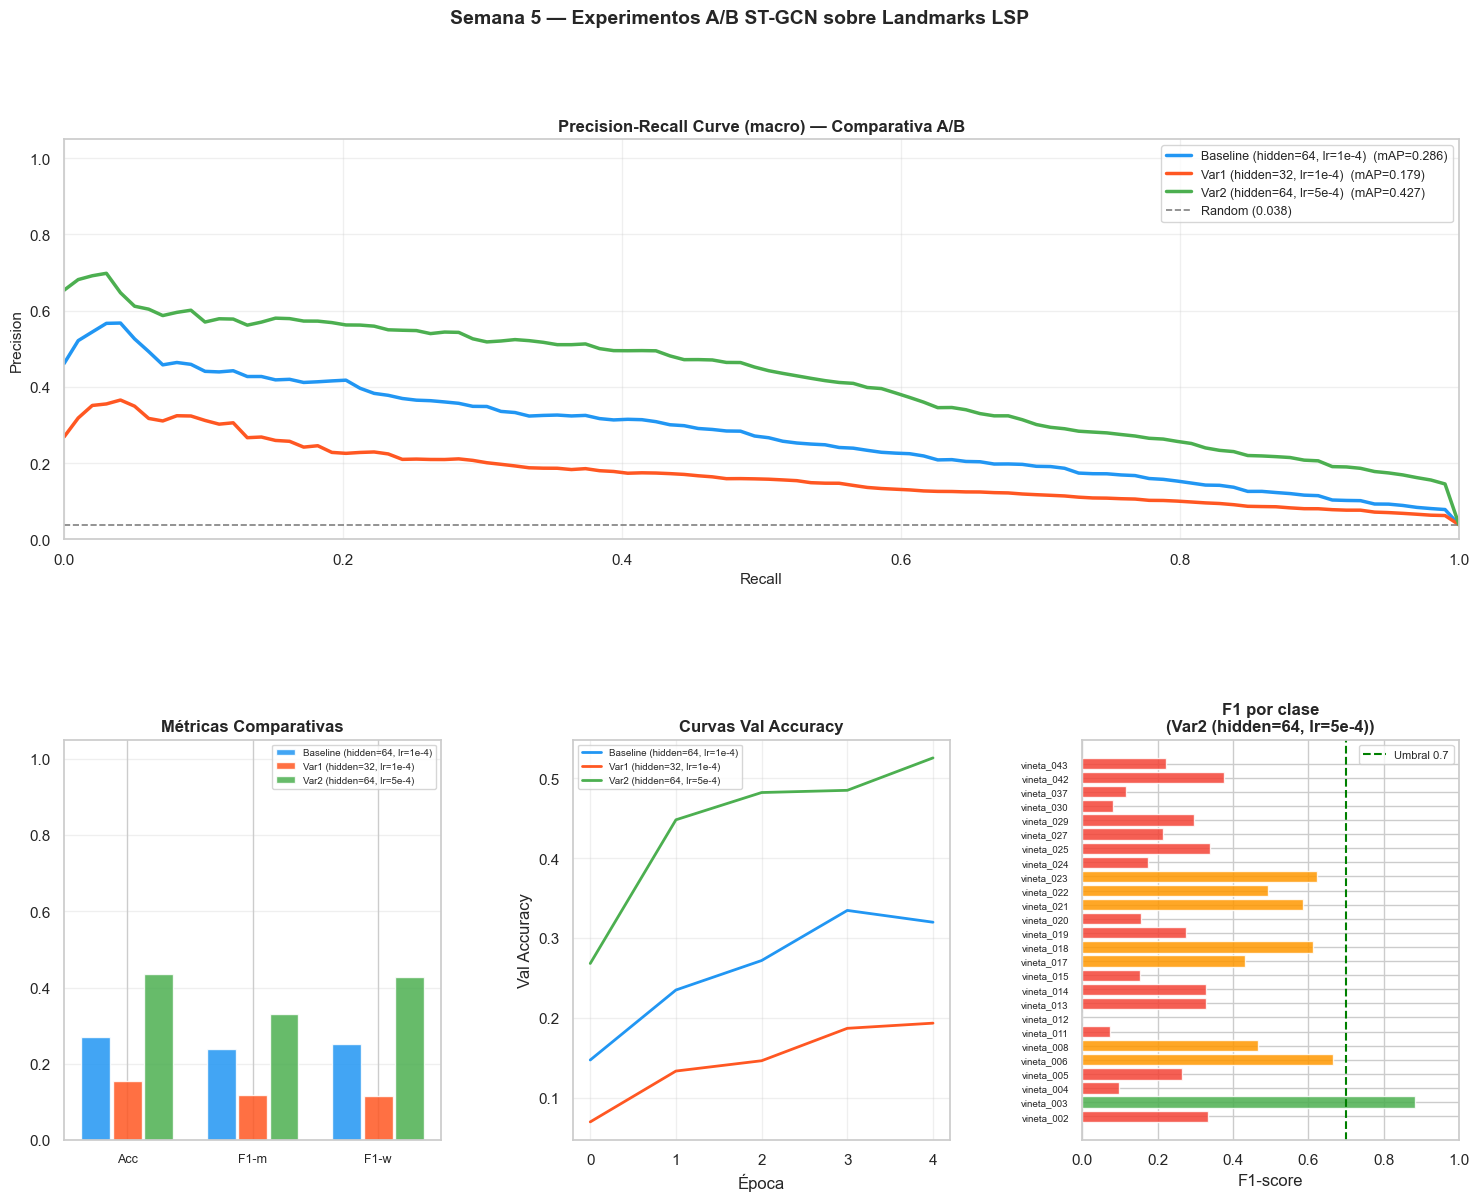

Gráfico guardado: data/semana5_experimentos_ab.png


In [8]:
# ── Gráfico clave: PR Curve + barplot métricas + F1 por clase ─────────────
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.35)
fig.suptitle('Semana 5 — Experimentos A/B ST-GCN sobre Landmarks LSP', fontsize=14, fontweight='bold')

colors_exp = ['#2196F3', '#FF5722', '#4CAF50']
exp_items  = list(RESULTS.items())

# ── 1. PR Curve macro ──
ax_pr = fig.add_subplot(gs[0, :])
for (name, r), col in zip(exp_items, colors_exp):
    precisions, recalls = [], []
    for cls_idx in range(N_CLASSES):
        y_bin = (r['y_true'] == cls_idx).astype(int)
        if y_bin.sum() == 0: continue
        p, rc, _ = precision_recall_curve(y_bin, r['y_prob'][:, cls_idx])
        precisions.append(p); recalls.append(rc)
    mean_rc   = np.linspace(0, 1, 100)
    mean_prec = np.mean([np.interp(mean_rc, rc[::-1], p[::-1])
                         for p, rc in zip(precisions, recalls)], axis=0)
    ap = average_precision_score(np.eye(N_CLASSES)[r['y_true']], r['y_prob'], average='macro')
    ax_pr.plot(mean_rc, mean_prec, lw=2.5, color=col,
               label=f'{name.replace(chr(10)," ")}  (mAP={ap:.3f})')

ax_pr.axhline(1/N_CLASSES, ls='--', color='gray', lw=1.2, label=f'Random ({1/N_CLASSES:.3f})')
ax_pr.set_xlabel('Recall', fontsize=11); ax_pr.set_ylabel('Precision', fontsize=11)
ax_pr.set_title('Precision-Recall Curve (macro) — Comparativa A/B', fontweight='bold', fontsize=12)
ax_pr.legend(fontsize=9, loc='upper right'); ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)
ax_pr.grid(True, alpha=0.3)

# ── 2. Barplot métricas ──
ax_bar = fig.add_subplot(gs[1, 0])
metrics_plt = ['Accuracy', 'F1-macro', 'F1-weighted']
x = np.arange(len(metrics_plt))
w = 0.25
for i, (rname, col) in enumerate(zip(df_results.index, colors_exp)):
    vals = [df_results.loc[rname, m] for m in metrics_plt]
    ax_bar.bar(x + i*w - w, vals, w*0.92, label=rname.replace('\n',' '),
               color=col, alpha=0.85, edgecolor='white')
ax_bar.set_xticks(x); ax_bar.set_xticklabels(['Acc','F1-m','F1-w'], fontsize=9)
ax_bar.set_ylim(0, 1.05); ax_bar.legend(fontsize=7)
ax_bar.set_title('Métricas Comparativas', fontweight='bold'); ax_bar.grid(True, alpha=0.3, axis='y')

# ── 3. Curvas val_acc ──
ax_crv = fig.add_subplot(gs[1, 1])
for (name, r), col in zip(exp_items, colors_exp):
    if r['history'].get('val_acc'):
        ax_crv.plot(r['history']['val_acc'], lw=2, color=col, label=name.replace('\n',' '))
ax_crv.set_xlabel('Época'); ax_crv.set_ylabel('Val Accuracy')
ax_crv.set_title('Curvas Val Accuracy', fontweight='bold')
ax_crv.legend(fontsize=7); ax_crv.grid(True, alpha=0.3)

# ── 4. F1 por clase — mejor variante ──
ax_cls = fig.add_subplot(gs[1, 2])
best_r   = RESULTS[best_name]
report_d = classification_report(best_r['y_true'], best_r['y_pred'],
                                  target_names=CLASS_NAMES, output_dict=True, zero_division=0)
f1_cls   = [report_d[cn]['f1-score'] for cn in CLASS_NAMES]
clrs_cls = ['#4CAF50' if f>=0.7 else ('#FF9800' if f>=0.4 else '#F44336') for f in f1_cls]
ax_cls.barh(CLASS_NAMES, f1_cls, color=clrs_cls, alpha=0.85)
ax_cls.axvline(0.7, ls='--', color='green', lw=1.5, label='Umbral 0.7')
ax_cls.set_xlabel('F1-score'); ax_cls.set_xlim(0, 1)
ax_cls.set_title(f'F1 por clase\n({best_name.replace(chr(10)," ")})', fontweight='bold')
ax_cls.legend(fontsize=8); ax_cls.tick_params(axis='y', labelsize=7)

plt.savefig('data/semana5_experimentos_ab.png', dpi=130, bbox_inches='tight')
plt.show()
print('Gráfico guardado: data/semana5_experimentos_ab.png')

In [9]:
# ── Feature set y pipeline — confirmación cero leakage ────────────────────
print('='*65)
print('FEATURE SET Y PIPELINE')
print('='*65)
print()
print('FEATURES USADAS (todos los experimentos):')
print('  - Landmarks MediaPipe Holistic: 42 manos + 33 pose = 75 keypoints')
print('  - Formato: [T=30, N=75, C=3]  (x, y, z normalizados [0,1])')
print('  - Normalización posicional: coordenadas relativas a muñeca derecha')
print('  - Extraídas 1 vez, guardadas como .npy (26.5 KB/segmento)')
print()
print('FEATURES AÑADIDAS/QUITADAS por variante:')
print('  Baseline → Var1: hidden_channels 64→32 (-50% params en capas GCN)')
print('  Baseline → Var2: ninguna feature; solo lr 1e-4→5e-4')
print()
print('TRANSFORMACIONES (fit exclusivo en TRAIN):')
print('  - WeightedRandomSampler: peso=1/count_clase (solo train)')
print('  - Augmentación: ruido gaussiano σ=0.01 + flip horizontal (solo train)')
print('  - CosineAnnealingLR scheduler')
print()

# Verificar leakage
print('CONFIRMACIÓN CERO DATA LEAKAGE:')
leakage = False
for vid in df['video_path'].unique():
    tr = df[(df['video_path']==vid) & (df['split']=='train')]
    te = df[(df['video_path']==vid) & (df['split']=='test')]
    for _, r1 in tr.iterrows():
        for _, r2 in te.iterrows():
            if max(0, min(r1['end_frame'], r2['end_frame']) -
                      max(r1['start_frame'], r2['start_frame'])) > 0:
                leakage = True; break
        if leakage: break
    if leakage: break

split_stats = df.groupby('split')[['clase']].apply(lambda x: x['clase'].nunique())
for sp in ['train', 'val', 'test']:
    n_s = len(df[df['split']==sp])
    n_v = df[df['split']==sp]['video_path'].nunique()
    n_c = df[df['split']==sp]['clase'].nunique()
    print(f'  {sp:5s}: {n_s:5d} segs | {n_v} videos | {n_c} clases')
print(f'  Solapamiento frames train/test: {"SÍ ← PROBLEMA" if leakage else "NO ✓"}')
print(f'  Tipo split: TEMPORAL (primeros 70% → train, sig. 15% → val, últimos 15% → test)')

FEATURE SET Y PIPELINE

FEATURES USADAS (todos los experimentos):
  - Landmarks MediaPipe Holistic: 42 manos + 33 pose = 75 keypoints
  - Formato: [T=30, N=75, C=3]  (x, y, z normalizados [0,1])
  - Normalización posicional: coordenadas relativas a muñeca derecha
  - Extraídas 1 vez, guardadas como .npy (26.5 KB/segmento)

FEATURES AÑADIDAS/QUITADAS por variante:
  Baseline → Var1: hidden_channels 64→32 (-50% params en capas GCN)
  Baseline → Var2: ninguna feature; solo lr 1e-4→5e-4

TRANSFORMACIONES (fit exclusivo en TRAIN):
  - WeightedRandomSampler: peso=1/count_clase (solo train)
  - Augmentación: ruido gaussiano σ=0.01 + flip horizontal (solo train)
  - CosineAnnealingLR scheduler

CONFIRMACIÓN CERO DATA LEAKAGE:


  train:  5051 segs | 26 videos | 26 clases
  val  :  1085 segs | 26 videos | 26 clases
  test :  1099 segs | 26 videos | 26 clases
  Solapamiento frames train/test: NO ✓
  Tipo split: TEMPORAL (primeros 70% → train, sig. 15% → val, últimos 15% → test)


In [10]:
# ── Validación: holdout test set ──────────────────────────────────────────
print('='*65)
print('VALIDACIÓN — HOLDOUT TEST SET')
print('='*65)
print()
print('Estrategia: Temporal holdout por video')
print('  Train 70% → Val 15% → Test 15% (fracs de segmentos temporales/video)')
print('  Val: early stopping únicamente (no para selección de hiperparámetros)')
print('  Test: evaluación final, una sola vez por variante')
print()

best_r = RESULTS[best_name]
print(f'Reporte por clase — {best_name.replace(chr(10)," ")}:')
print(classification_report(best_r['y_true'], best_r['y_pred'],
                             target_names=CLASS_NAMES, zero_division=0, digits=3))

problematic = [(cn, report_d[cn]['f1-score'])
               for cn in CLASS_NAMES if report_d[cn]['f1-score'] < 0.5]
if problematic:
    print('Clases con F1 < 0.5 (candidatas a más datos / augmentación):')
    for cn, f1 in sorted(problematic, key=lambda x: x[1]):
        print(f'  {cn}: F1={f1:.3f}, support={int(report_d[cn]["support"])}')

VALIDACIÓN — HOLDOUT TEST SET

Estrategia: Temporal holdout por video
  Train 70% → Val 15% → Test 15% (fracs de segmentos temporales/video)
  Val: early stopping únicamente (no para selección de hiperparámetros)
  Test: evaluación final, una sola vez por variante

Reporte por clase — Var2 (hidden=64, lr=5e-4):
              precision    recall  f1-score   support

  vineta_002      0.264     0.452     0.333        31
  vineta_003      0.940     0.830     0.882       171
  vineta_004      0.120     0.083     0.098        36
  vineta_005      0.500     0.179     0.264        39
  vineta_006      0.712     0.627     0.667        59
  vineta_008      0.560     0.400     0.467        35
  vineta_011      0.056     0.111     0.074        18
  vineta_012      0.000     0.000     0.000        30
  vineta_013      0.255     0.462     0.329        26
  vineta_014      0.286     0.385     0.328        26
  vineta_015      0.357     0.098     0.154        51
  vineta_017      0.356     0.553     

In [11]:
# ── Log completo ──────────────────────────────────────────────────────────
log_path = LOG_DIR / 'semana5_experimentos.txt'
with open(log_path, 'w', encoding='utf-8') as f:
    f.write('='*72 + '\n')
    f.write('SEMANA 5 — EXPERIMENTOS A/B — SISTEMA LSP\n')
    f.write(f'Fecha: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}\n')
    f.write('='*72 + '\n\n')
    f.write('CONFIGURACIÓN COMÚN\n')
    f.write(f'  Modelo:    ST-GCN (Spatial-Temporal GCN)\n')
    f.write(f'  Datos:     Landmarks MediaPipe Holistic [T=30, N=75, C=3]\n')
    f.write(f'  Dataset:   {len(df)} segs con landmarks | 26 clases\n')
    f.write(f'  Epochs:    {EPOCHS} | Batch: {BATCH} | Device: {DEVICE}\n')
    f.write(f'  Optimizer: AdamW + CosineAnnealingLR\n\n')
    f.write('DISEÑO A/B (un cambio por vez)\n')
    f.write('  Baseline : hidden_channels=64, lr=1e-4\n')
    f.write('  Var1     : hidden_channels=32, lr=1e-4  ← cambio: hidden size ↓\n')
    f.write('  Var2     : hidden_channels=64, lr=5e-4  ← cambio: learning rate ↑\n\n')
    f.write('TABLA COMPARATIVA\n')
    f.write(df_results.to_string() + '\n\n')
    f.write(f'MEJOR: {best_name.replace(chr(10)," ")} — F1-macro={best_f1:.4f} (Δ={delta:+.4f})\n\n')
    f.write('PIPELINE Y FEATURES\n')
    f.write('  Input:        .npy landmarks [30, 75, 3] por segmento\n')
    f.write('  Normalización: keypoints relativos a muñeca derecha\n')
    f.write('  Augmentación: ruido σ=0.01 + flip horizontal (solo train)\n')
    f.write('  Balanceo:     WeightedRandomSampler (solo train)\n\n')
    f.write('LEAKAGE CHECK\n')
    f.write(f'  Solapamiento frames train/test: {"SÍ" if leakage else "NO"}\n')
    f.write('  Split tipo: TEMPORAL por video (70/15/15)\n\n')
    f.write('REPORTE CLASIFICACIÓN — MEJOR VARIANTE\n')
    f.write(classification_report(best_r['y_true'], best_r['y_pred'],
                                   target_names=CLASS_NAMES, zero_division=0, digits=3))

print(f'Log guardado: {log_path}')
print('\n' + '='*65)
print('RESUMEN EJECUTIVO — SEMANA 5')
print('='*65)
print(f'  Modelo:   ST-GCN sobre landmarks MediaPipe')
print(f'  Dataset:  {len(df)} segs | 26 clases | random baseline={1/N_CLASSES:.4f}')
for name, r in RESULTS.items():
    marker = ' ← MEJOR' if name == best_name else ''
    nm = name.replace('\n', ' ')
    print(f'  {nm:35s}: Acc={r["accuracy"]:.4f} | F1-m={r["f1_macro"]:.4f}{marker}')
print(f'\n  Conclusión: {best_name.replace(chr(10)," ")} mejor variante (Δ F1={delta:+.4f})')
print(f'  Próximo paso: entrenar más épocas en Colab GPU + modelo Fusión CNN+GCN')

Log guardado: logs/semana5_experimentos.txt

RESUMEN EJECUTIVO — SEMANA 5
  Modelo:   ST-GCN sobre landmarks MediaPipe
  Dataset:  7235 segs | 26 clases | random baseline=0.0385
  Baseline (hidden=64, lr=1e-4)      : Acc=0.2712 | F1-m=0.2389
  Var1 (hidden=32, lr=1e-4)          : Acc=0.1538 | F1-m=0.1185
  Var2 (hidden=64, lr=5e-4)          : Acc=0.4349 | F1-m=0.3307 ← MEJOR

  Conclusión: Var2 (hidden=64, lr=5e-4) mejor variante (Δ F1=+0.0918)
  Próximo paso: entrenar más épocas en Colab GPU + modelo Fusión CNN+GCN
